# 04. CNN Training

This notebook trains the baseline convolutional neural network (CNN) developed for binary classification of cracked and uncracked concrete images from the SDNET2018 dataset.

The notebook covers model initialization, training, validation, model checkpointing and recording of training history. Model evaluation on the independent test set is performed in the subsequent evaluation notebook.

## 1. Imports and Reproducibility

In [12]:
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch version:", torch.__version__)
print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.11.0+cpu
Device: cpu


## 2. Upload SDNET2018 Dataset

In [2]:
from google.colab import files

uploaded = files.upload()  # opens a file picker; select your zip from the desktop

Saving sdnet2018.zip to sdnet2018.zip


In [3]:
!ls -lh /content/sdnet2018.zip

-rw-r--r-- 1 root root 509M Sep 17 09:51 /content/sdnet2018.zip


## 3.Extract Dataset

In [4]:
!rm -rf /content/sdnet2018
!unzip -q /content/sdnet2018.zip -d /content/sdnet2018

In [5]:
from pathlib import Path
print(len(list(Path("/content/sdnet2018").rglob("*.jpg"))))

56092


## 4. Define Project and Dataset Paths

In [6]:
!git clone https://github.com/yoolmalaak/concrete-crack-and-fracture-analysis.git

Cloning into 'concrete-crack-and-fracture-analysis'...
remote: Enumerating objects: 40, done.
remote: Counting objects: 100% (40/40), done.
remote: Compressing objects: 100% (32/32), done.
remote: Total 40 (delta 6), reused 36 (delta 3), pack-reused 0 (from 0)
Receiving objects: 100% (40/40), 8.30 MiB | 17.52 MiB/s, done.
Resolving deltas: 100% (6/6), done.


In [7]:
from pathlib import Path

PROJECT_ROOT = Path("/content/concrete-crack-and-fracture-analysis")
SDNET_ROOT = Path("/content/sdnet2018/sdnet2018")

print("Project exists:", PROJECT_ROOT.exists())
print("Dataset exists:", SDNET_ROOT.exists())
print("Dataset path:", SDNET_ROOT)

Project exists: True
Dataset exists: True
Dataset path: /content/sdnet2018/sdnet2018


## 5. Load and Verify Dataset

In [10]:
surfaces = ["deck", "pavement", "wall"]
classes = ["crack_dataset", "uncrack_dataset"]

for surface in surfaces:
    for class_name in classes:
        folder = SDNET_ROOT / surface / class_name
        images = list(folder.glob("*.jpg"))

        print(
            f"{surface}/{class_name}: "
            f"{len(images)} images"
        )

total_images = len(list(SDNET_ROOT.rglob("*.jpg")))

print("\nTotal images:", total_images)

deck/crack_dataset: 2025 images
deck/uncrack_dataset: 11595 images
pavement/crack_dataset: 2608 images
pavement/uncrack_dataset: 21726 images
wall/crack_dataset: 3851 images
wall/uncrack_dataset: 14287 images

Total images: 56092


## 6. Build Dataset Metadata

In [13]:
records = []

for surface in surfaces:
    for class_name in classes:
        folder = SDNET_ROOT / surface / class_name

        class_id = 1 if class_name == "crack_dataset" else 0
        label = "cracked" if class_id == 1 else "uncracked"

        for image_path in folder.glob("*.jpg"):
            records.append({
                "image_path": str(image_path),
                "surface": surface,
                "label": label,
                "class_id": class_id
            })

metadata_df = pd.DataFrame(records)

print("Total images:", len(metadata_df))

print("\nClass distribution:")
print(metadata_df["label"].value_counts())

print("\nSurface distribution:")
print(metadata_df["surface"].value_counts())

Total images: 56092

Class distribution:
label
uncracked    47608
cracked       8484
Name: count, dtype: int64

Surface distribution:
surface
pavement    24334
wall        18138
deck        13620
Name: count, dtype: int64


## 7. Verify Dataset Splits

In [14]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    metadata_df,
    train_size=39264,
    stratify=metadata_df["class_id"],
    random_state=SEED
)

val_df, test_df = train_test_split(
    temp_df,
    train_size=8414,
    stratify=temp_df["class_id"],
    random_state=SEED
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Training set:", len(train_df))
print("Validation set:", len(val_df))
print("Test set:", len(test_df))
print("Total:", len(train_df) + len(val_df) + len(test_df))

Training set: 39264
Validation set: 8414
Test set: 8414
Total: 56092


In [15]:
print("Training class distribution:")
print(train_df["label"].value_counts())

print("\nValidation class distribution:")
print(val_df["label"].value_counts())

print("\nTest class distribution:")
print(test_df["label"].value_counts())

print("\nTraining surface distribution:")
print(train_df["surface"].value_counts())

print("\nValidation surface distribution:")
print(val_df["surface"].value_counts())

print("\nTest surface distribution:")
print(test_df["surface"].value_counts())

Training class distribution:
label
uncracked    33325
cracked       5939
Name: count, dtype: int64

Validation class distribution:
label
uncracked    7141
cracked      1273
Name: count, dtype: int64

Test class distribution:
label
uncracked    7142
cracked      1272
Name: count, dtype: int64

Training surface distribution:
surface
pavement    17067
wall        12692
deck         9505
Name: count, dtype: int64

Validation surface distribution:
surface
pavement    3649
wall        2712
deck        2053
Name: count, dtype: int64

Test surface distribution:
surface
pavement    3618
wall        2734
deck        2062
Name: count, dtype: int64


## 8. Define Image Transformations

In [16]:
from torchvision import transforms
from torchvision.transforms import InterpolationMode

train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(
        10,
        interpolation=InterpolationMode.BILINEAR
    ),
    transforms.CenterCrop((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Training transformation:")
print(train_transform)

print("\nEvaluation transformation:")
print(eval_transform)

Training transformation:
Compose(
    Resize(size=(256, 256), interpolation=bilinear, max_size=None, antialias=True)
    RandomHorizontalFlip(p=0.5)
    RandomRotation(degrees=[-10.0, 10.0], interpolation=bilinear, expand=False, fill=0)
    CenterCrop(size=(224, 224))
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)

Evaluation transformation:
Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


## 9. Create PyTorch Dataset

In [17]:
from torch.utils.data import Dataset
from PIL import Image

class ConcreteCrackDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        row = self.dataframe.iloc[index]

        image = Image.open(row["image_path"]).convert("RGB")
        label = torch.tensor(row["class_id"], dtype=torch.float32)

        if self.transform:
            image = self.transform(image)

        return image, label


train_dataset = ConcreteCrackDataset(
    train_df,
    transform=train_transform
)

val_dataset = ConcreteCrackDataset(
    val_df,
    transform=eval_transform
)

test_dataset = ConcreteCrackDataset(
    test_df,
    transform=eval_transform
)

print("Training dataset:", len(train_dataset))
print("Validation dataset:", len(val_dataset))
print("Test dataset:", len(test_dataset))

Training dataset: 39264
Validation dataset: 8414
Test dataset: 8414


## 10. Inspect Dataset Samples

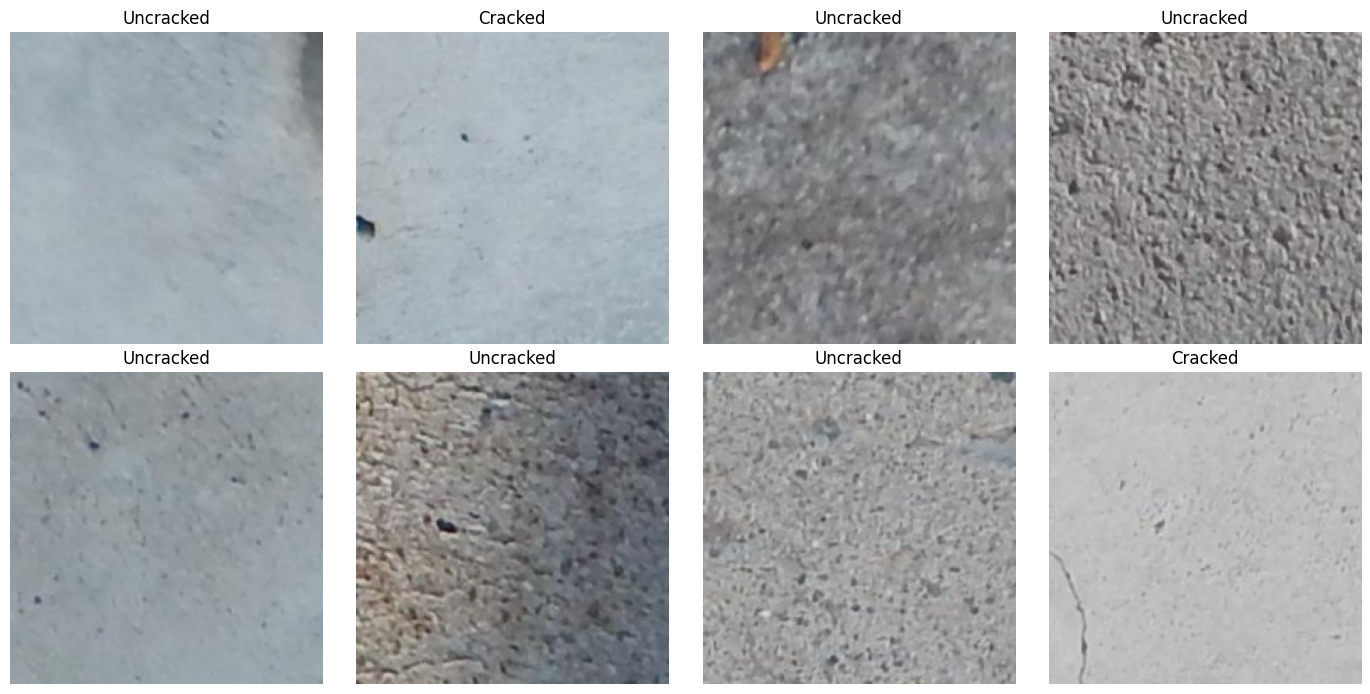

In [18]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 4, figsize=(14, 7))

for i, ax in enumerate(axes.flat):
    image, label = train_dataset[i]

    image_display = image.permute(1, 2, 0).numpy()

    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    image_display = image_display * std + mean
    image_display = np.clip(image_display, 0, 1)

    ax.imshow(image_display)
    ax.set_title("Cracked" if label.item() == 1 else "Uncracked")
    ax.axis("off")

plt.tight_layout()
plt.show()

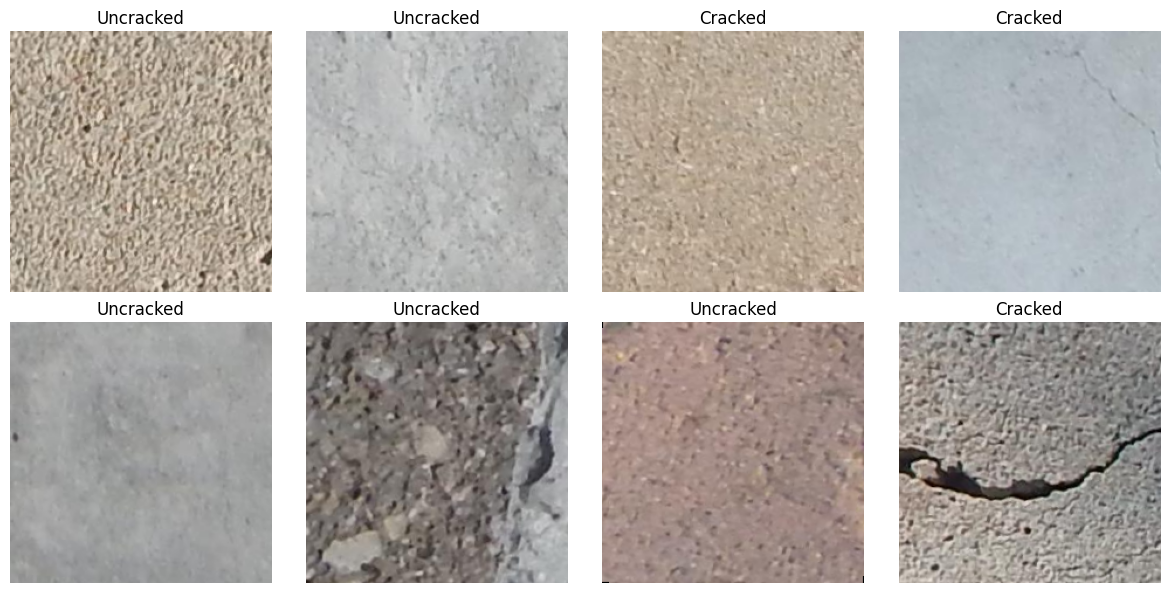

In [19]:
mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for ax in axes.flat:
    index = np.random.randint(len(train_dataset))
    image, label = train_dataset[index]

    image = image * std + mean
    image = image.clamp(0, 1)

    ax.imshow(image.permute(1, 2, 0))
    ax.set_title("Cracked" if label.item() == 1 else "Uncracked")
    ax.axis("off")

plt.tight_layout()
plt.show()

## 11. Create DataLoaders

In [20]:
from torch.utils.data import DataLoader

BATCH_SIZE = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

print("Batch size:", BATCH_SIZE)
print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Batch size: 64
Training batches: 614
Validation batches: 132
Test batches: 132


## 12. Inspect a Training Batch

In [21]:
images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Image data type:", images.dtype)
print("Label data type:", labels.dtype)
print("Device:", images.device)

print("\nNumber of cracked images:", int((labels == 1).sum()))
print("Number of uncracked images:", int((labels == 0).sum()))

/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Image batch shape: torch.Size([64, 3, 224, 224])
Label batch shape: torch.Size([64])
Image data type: torch.float32
Label data type: torch.float32
Device: cpu

Number of cracked images: 8
Number of uncracked images: 56


In [22]:
images_gpu = images.to(device)
labels_gpu = labels.to(device)

print("\nAfter GPU transfer:")
print("Images device:", images_gpu.device)
print("Labels device:", labels_gpu.device)


After GPU transfer:
Images device: cpu
Labels device: cpu


## 13. Define Baseline CNN Architecture

In [23]:
import torch.nn as nn

class BaselineCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


model = BaselineCNN()

print(model)

BaselineCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): AdaptiveAvgPool2d(output_size=(1, 1))
    (1): Flatten(start_dim=1, end_dim=-1)
    (2): Linear(in_features=128, out_features=1, bias=True)
  )
)


## 14. Initialize and Test Baseline CNN

In [24]:
model = BaselineCNN().to(device)

sample_images, sample_labels = next(iter(train_loader))
sample_images = sample_images.to(device)

with torch.no_grad():
    sample_outputs = model(sample_images)

print("Input shape:", sample_images.shape)
print("Output shape:", sample_outputs.shape)
print("Model device:", next(model.parameters()).device)

Input shape: torch.Size([64, 3, 224, 224])
Output shape: torch.Size([64, 1])
Model device: cpu


## 15. Define Loss Function and Optimizer

In [25]:
num_uncracked = (train_df["class_id"] == 0).sum()
num_cracked = (train_df["class_id"] == 1).sum()

pos_weight = num_uncracked / num_cracked

pos_weight_tensor = torch.tensor(
    [pos_weight],
    dtype=torch.float32,
    device=device
)

criterion = nn.BCEWithLogitsLoss(
    pos_weight=pos_weight_tensor
)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

print("Uncracked training images:", num_uncracked)
print("Cracked training images:", num_cracked)
print("Positive class weight:", round(pos_weight, 4))
print("Learning rate:", 0.001)

Uncracked training images: 33325
Cracked training images: 5939
Positive class weight: 5.6112
Learning rate: 0.001


## 16. GPU Training Speed Check

In [27]:
import time

images, labels = next(iter(train_loader))

images = images.to(device, non_blocking=True)
labels = labels.to(device, non_blocking=True).unsqueeze(1)

optimizer.zero_grad()

start_time = time.time()

outputs = model(images)
loss = criterion(outputs, labels)
loss.backward()
optimizer.step()

# torch.cuda.synchronize() # Removed as CUDA is not available

elapsed_time = time.time() - start_time

print("Batch size:", images.size(0))
print("Device:", images.device)
print("Training loss:", round(loss.item(), 4))
print("One batch training time:", round(elapsed_time, 3), "seconds")

/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Batch size: 64
Device: cpu
Training loss: 1.2478
One batch training time: 11.076 seconds


## 17. Initialize Fresh Model for Training

In [28]:
model = BaselineCNN().to(device)

criterion = nn.BCEWithLogitsLoss(
    pos_weight=pos_weight_tensor
)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

print("Fresh model initialized.")
print("Model device:", next(model.parameters()).device)

Fresh model initialized.
Model device: cpu


## 18. Define Training and Validation Functions

In [29]:
import time

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True).unsqueeze(1)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        predictions = (torch.sigmoid(outputs) >= 0.5).float()
        correct += (predictions == labels).sum().item()
        total += labels.numel()

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy


def validate_one_epoch(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True).unsqueeze(1)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            predictions = (torch.sigmoid(outputs) >= 0.5).float()
            correct += (predictions == labels).sum().item()
            total += labels.numel()

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy


print("Training and validation functions defined successfully.")

Training and validation functions defined successfully.


## 19. Define Training Configuration

In [30]:
from pathlib import Path

NUM_EPOCHS = 10

best_val_loss = float("inf")

history = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": []
}

PROJECT_ROOT = Path("/content/concrete-crack-and-fracture-analysis")
SDNET_ROOT = Path("/content/sdnet2018/sdnet2018")

MODEL_DIR = PROJECT_ROOT / "trained_models"
RESULTS_DIR = PROJECT_ROOT / "results"

MODEL_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

BEST_MODEL_PATH = MODEL_DIR / "baseline_cnn_best.pth"

print("Number of epochs:", NUM_EPOCHS)
print("Best model path:", BEST_MODEL_PATH)

Number of epochs: 10
Best model path: /content/concrete-crack-and-fracture-analysis/trained_models/baseline_cnn_best.pth


## 20. Train the Baseline CNN

In [5]:
print("Starting training...\n")

for epoch in range(NUM_EPOCHS):
    epoch_start = time.time()

    train_loss, train_accuracy = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_accuracy = validate_one_epoch(
        model,
        val_loader,
        criterion,
        device
    )

    history["train_loss"].append(train_loss)
    history["train_accuracy"].append(train_accuracy)
    history["val_loss"].append(val_loss)
    history["val_accuracy"].append(val_accuracy)

    epoch_time = time.time() - epoch_start

    if val_loss < best_val_loss:
        best_val_loss = val_loss

        torch.save(
            {
                "epoch": epoch + 1,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "val_loss": val_loss,
                "val_accuracy": val_accuracy
            },
            BEST_MODEL_PATH
        )

        checkpoint_status = "Saved"
    else:
        checkpoint_status = ""

    print(
        f"Epoch [{epoch + 1}/{NUM_EPOCHS}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_accuracy:.4f} | "
        f"Time: {epoch_time:.1f}s | "
        f"{checkpoint_status}"
    )

Starting training...



NameError: name 'NUM_EPOCHS' is not defined

In [4]:
from pathlib import Path

checkpoint = Path(
    "/content/concrete-crack-and-fracture-analysis/trained_models/baseline_cnn_best.pth"
)

print("Exists:", checkpoint.exists())

if checkpoint.exists():
    print("Size:", round(checkpoint.stat().st_size / (1024 ** 2), 2), "MB")

Exists: False
